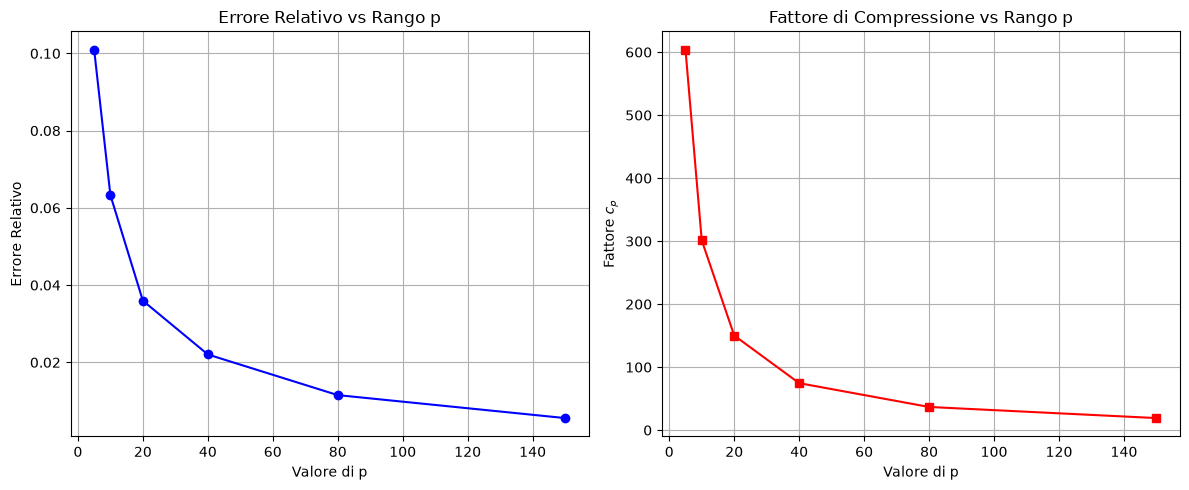

In [9]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Caricamento e conversione dell'immagine in scala di grigi
A = plt.imread('IMG_8164.jpeg')
if A.ndim == 3:
    A = np.mean(A, axis=2)

# 2. Decomposizione SVD della matrice immagine A
U, S, Vt = np.linalg.svd(A, full_matrices=False)
m, n = A.shape
rango_max = len(S)

# Scegliamo una lista di valori di p da testare
valori_p = [5, 10, 20, 40, 80, 150]
valori_p = [p for p in valori_p if p <= rango_max]

errori = []
compressioni = []

norm_A = np.linalg.norm(A, 2)

for p in valori_p:
    # Calcolo della matrice approssimata Ap
    Ap = U[:, :p] @ np.diag(S[:p]) @ Vt[:p, :]
    
    # Calcolo dell'errore relativo in norma 2
    errore_relativo = np.linalg.norm(A - Ap, 2) / norm_A
    errori.append(errore_relativo)
    
    # Calcolo del fattore di compressione cp
    cp = (1.0 / p) * min(m, n) - 1.0
    compressioni.append(cp)

# 3. Plot dei risultati
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(valori_p, errori, marker='o', color='b', linestyle='-')
plt.title('Errore Relativo vs Rango p')
plt.xlabel('Valore di p')
plt.ylabel('Errore Relativo')
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(valori_p, compressioni, marker='s', color='r', linestyle='-')
plt.title('Fattore di Compressione vs Rango p')
plt.xlabel('Valore di p')
plt.ylabel('Fattore $c_p$')
plt.grid(True)

plt.tight_layout()
plt.show()

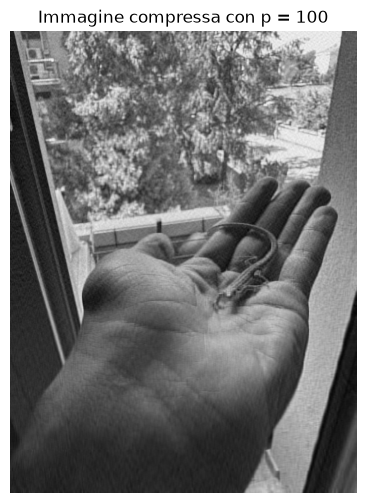

In [13]:
from PIL import Image, ImageOps
import numpy as np
import matplotlib.pyplot as plt

# 1. Carica l'immagine applicando la correzione automatica dell'orientamento EXIF
img = Image.open('IMG_8164.jpeg')
img = ImageOps.exif_transpose(img)

# 2. Converti in scala di grigi e trasforma in matrice NumPy
img_gray = img.convert('L')
A = np.array(img_gray, dtype=float)

# Da qui in poi puoi rieseguire il codice SVD e la visualizzazione di Ap
U, S, Vt = np.linalg.svd(A, full_matrices=False)
p_scelto = 100
Ap_scelto = U[:, :p_scelto] @ np.diag(S[:p_scelto]) @ Vt[:p_scelto, :]

plt.figure(figsize=(6, 6))
plt.imshow(Ap_scelto, cmap='gray')
plt.title(f'Immagine compressa con p = {p_scelto}')
plt.axis('off')
plt.show()

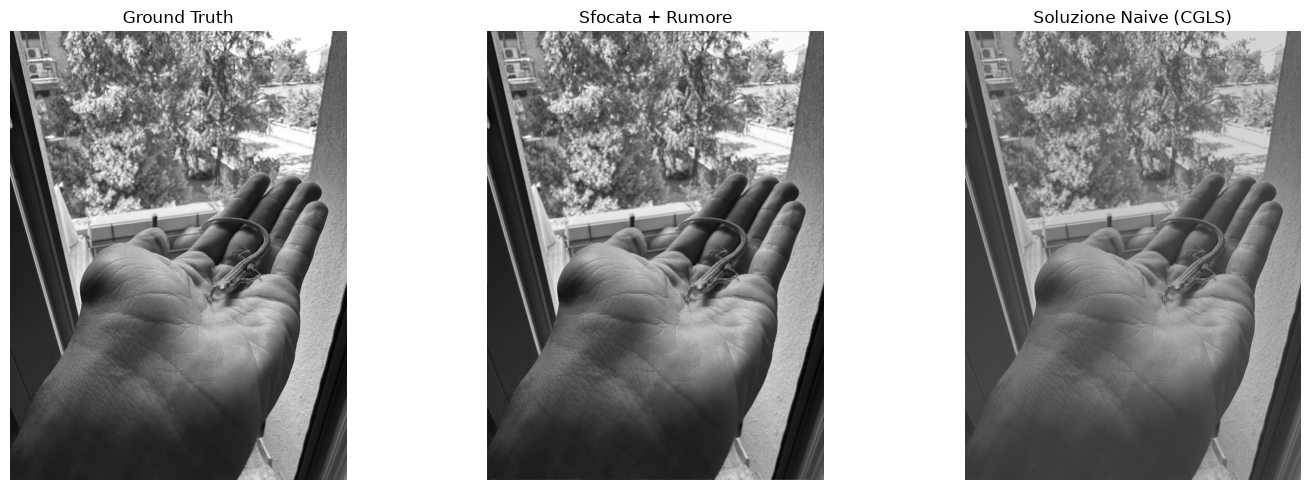

In [17]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image, ImageOps
import ProblemiInversi.operators as op
import ProblemiInversi.utilities as ut
import ProblemiInversi.solvers as sol

# 1. Carichiamo l'immagine ground truth (X_true)
img = Image.open('IMG_8164.jpeg')
img = ImageOps.exif_transpose(img)
X_true = np.array(img.convert('L'), dtype=float)

# 2. Creiamo il problema test (Sfuocamento + Rumore)
# Creiamo un kernel gaussiano 2D (k deve essere dispari, es. 11, sigma=2.0)
kernel = ut.gaussian2d_kernel(k=11, sigma=2.0)
A = op.ConvolutionOperator(kernel)

# Immagine sfocata pulita
y_clean = A(X_true)

# Aggiungiamo rumore gaussiano (es. livello 0.01)
noise_level = 0.01
y_delta = y_clean + ut.gaussian_noise(y_clean, noise_level)

# 3. Soluzione naive con CGLS (senza regolarizzazione)
cgls_solver = sol.CGLS(A)
x0 = np.zeros_like(y_delta)  # Punto di partenza a zeri
x_naive = cgls_solver.solve(y_delta, x0, kmax=50)

# 4. Visualizzazione dei risultati
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(X_true, cmap='gray')
axes[0].set_title('Ground Truth')

axes[1].imshow(y_delta, cmap='gray')
axes[1].set_title('Sfocata + Rumore')

axes[2].imshow(x_naive, cmap='gray')
axes[2].set_title('Soluzione Naive (CGLS)')

for ax in axes: 
    ax.axis('off')

plt.tight_layout()
plt.show()

 Lambda ottimale Tikhonov: 1.00e-10


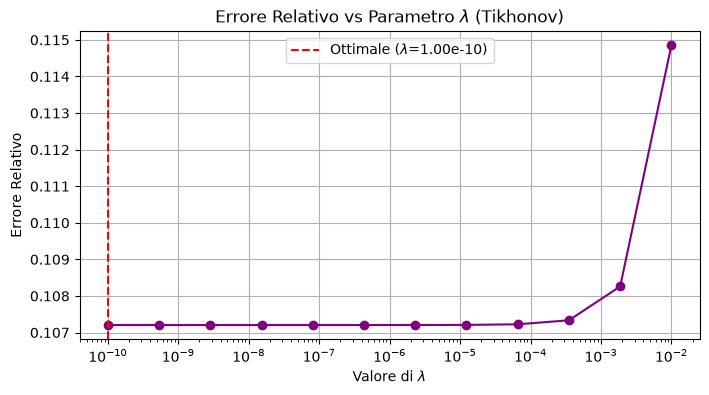

In [24]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image, ImageOps
import ProblemiInversi.operators as op
import ProblemiInversi.utilities as ut
import ProblemiInversi.solvers as sol

# 1. Caricamento e ridimensionamento dell'immagine
img = Image.open('IMG_8164.jpeg')
img = ImageOps.exif_transpose(img)
img = img.resize((256, 256))
X_true = np.array(img.convert('L'), dtype=float)

# 2. Creazione del problema test
kernel = ut.gaussian2d_kernel(k=11, sigma=2.0)
A = op.ConvolutionOperator(kernel)
y_clean = A(X_true)
y_delta = y_clean + ut.gaussian_noise(y_clean, 0.01)

# 3. Griglia di lambda estesa verso il basso
lambda_grid = np.logspace(-10, -2, 12)
errori_tikhonov = []
L_op = op.Identity()
x0 = np.zeros_like(y_delta)

for lmbda in lambda_grid:
    solver_tik = sol.CGLS(A, L=L_op, lmbda=lmbda)
    x_tik = solver_tik.solve(y_delta, x0=x0, kmax=20)
    errori_tikhonov.append(ut.rel_err(x_tik, X_true))

idx_opt = np.argmin(errori_tikhonov)
lambda_opt = lambda_grid[idx_opt]
print(f" Lambda ottimale Tikhonov: {lambda_opt:.2e}")

# 4. Visualizzazione del grafico dell'errore
plt.figure(figsize=(8, 4))
plt.semilogx(lambda_grid, errori_tikhonov, marker='o', color='purple')
plt.axvline(lambda_opt, color='red', linestyle='--', label=rf'Ottimale ($\lambda$={lambda_opt:.2e})')
plt.title(r'Errore Relativo vs Parametro $\lambda$ (Tikhonov)')
plt.xlabel(r'Valore di $\lambda$')
plt.ylabel('Errore Relativo')
plt.grid(True)
plt.legend()
plt.show()

Lambda ottimale TV: 1.00e+00


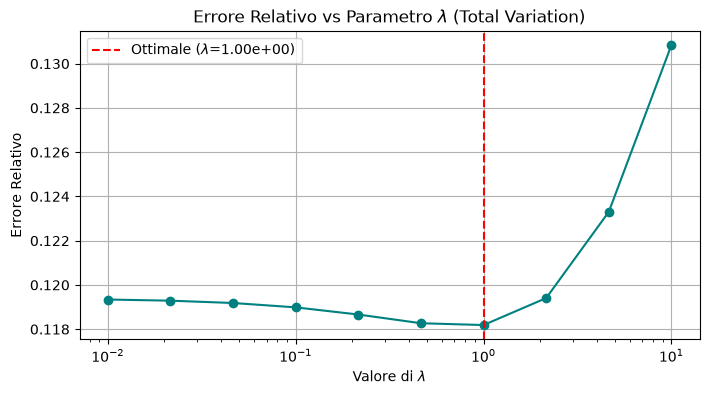

In [26]:
import numpy as np
import matplotlib.pyplot as plt
import ProblemiInversi.solvers as sol
import ProblemiInversi.utilities as ut

# Griglia di lambda estesa verso l'alto per la Total Variation
lambda_grid_tv = np.logspace(-2, 1, 10)
errori_tv = []

tv_solver = sol.ChambollePockTpV(A, img_shape=X_true.shape)

for lmbda in lambda_grid_tv:
    x_tv = tv_solver(y_delta, lmbda=lmbda, x_true=X_true, maxit=100)
    errori_tv.append(ut.rel_err(x_tv, X_true))

idx_opt_tv = np.argmin(errori_tv)
lambda_opt_tv = lambda_grid_tv[idx_opt_tv]
print(f"Lambda ottimale TV: {lambda_opt_tv:.2e}")

# Visualizzazione del grafico aggiornato
plt.figure(figsize=(8, 4))
plt.semilogx(lambda_grid_tv, errori_tv, marker='o', color='teal')
plt.axvline(lambda_opt_tv, color='red', linestyle='--', label=rf'Ottimale ($\lambda$={lambda_opt_tv:.2e})')
plt.title(r'Errore Relativo vs Parametro $\lambda$ (Total Variation)')
plt.xlabel(r'Valore di $\lambda$')
plt.ylabel('Errore Relativo')
plt.grid(True)
plt.legend()
plt.show()

In [27]:
# Parametri da testare per l'analisi di sensibilità
noise_levels = [0.01, 0.05]
kernel_sizes = [7, 15]

risultati_analisi = {}

for noise in noise_levels:
    for k_size in kernel_sizes:
        # 1. Nuovo problema test con parametri variati
        kernel_test = ut.gaussian2d_kernel(k=k_size, sigma=2.0)
        A_test = op.ConvolutionOperator(kernel_test)
        y_clean_test = A_test(X_true)
        y_delta_test = y_clean_test + ut.gaussian_noise(y_clean_test, noise)
        
        # 2. Test rapido con Tikhonov usando il lambda trovato
        solver_test = sol.CGLS(A_test, L=op.Identity(), lmbda=1e-4)
        x_rec = solver_test.solve(y_delta_test, x0=np.zeros_like(y_delta_test), kmax=20)
        
        # 3. Salvataggio metriche
        err = ut.rel_err(x_rec, X_true)
        psnr_val = ut.psnr(x_rec, X_true)
        risultati_analisi[(noise, k_size)] = (err, psnr_val)
        print(f"Rumore: {noise}, Kernel: {k_size}x{k_size} -> Errore: {err:.4f}, PSNR: {psnr_val:.2f} dB")

Rumore: 0.01, Kernel: 7x7 -> Errore: 0.1037, PSNR: -22.24 dB
Rumore: 0.01, Kernel: 15x15 -> Errore: 0.1074, PSNR: -22.54 dB
Rumore: 0.05, Kernel: 7x7 -> Errore: 0.3662, PSNR: -33.20 dB
Rumore: 0.05, Kernel: 15x15 -> Errore: 0.1862, PSNR: -27.33 dB


In [28]:
print(f"{'Rumore':<10} | {'Kernel':<10} | {'Errore Relativo':<15} | {'PSNR':<10}")
print("-" * 55)
for (noise, k_size), (err, psnr_val) in risultati_analisi.items():
    print(f"{noise:<10} | {k_size}x{k_size:<8} | {err:<15.4f} | {psnr_val:.2f} dB")

Rumore     | Kernel     | Errore Relativo | PSNR      
-------------------------------------------------------
0.01       | 7x7        | 0.1037          | -22.24 dB
0.01       | 15x15       | 0.1074          | -22.54 dB
0.05       | 7x7        | 0.3662          | -33.20 dB
0.05       | 15x15       | 0.1862          | -27.33 dB


# Relazione Homework 4: Problemi Inversi e Imaging

Questa relazione documenta lo svolgimento completo dell'**Homework 4** del corso di Problemi Inversi e Calcolo Numerico, focalizzato sul ripristino di immagini degradate da sfuocamento (blur) e rumore.

---

## 1. Introduzione e Obiettivi
Nei problemi di imaging, l'acquisizione di un'immagine può essere modellata come un sistema lineare perturbato:
$$y = Ax + e$$
dove:
- $x$ è l'immagine originale (*ground truth*).
- $A$ è un operatore lineare (nel nostro caso, una convoluzione che rappresenta la Point Spread Function - PSF di sfuocamento).
- $y$ è l'immagine acquisita, affetta da sfuocamento.
- $e$ è il rumore additivo (es. rumore gaussiano).

Poiché l'operatore di sfuocamento è fortemente ill-posed (mal posto), l'inversione diretta amplifica in modo catastrofico il rumore. L'obiettivo dell'homework è implementare e confrontare diverse tecniche di regolarizzazione (**Tikhonov** e **Total Variation**) per ottenere una ricostruzione stabile e di alta qualità.

---

## 2. Struttura della Libreria e Setup Iniziale
Il progetto sfrutta i moduli forniti nella cartella `ProblemiInversi`:
- `operators.py`: Definisce gli operatori lineari (`ConvolutionOperator`, `Identity`, `Gradient`).
- `solvers.py`: Contiene i solutori numerici (`CGLS`, `ChambollePockTpV`).
- `utilities.py`: Fornisce funzioni per la generazione di kernel gaussiano, rumore e calcolo delle metriche di errore (`rel_err`, `psnr`, `ssim`).

---

## 3. Implementazione Passo-Passo

### 3.1 Creazione del Problema Test
Si parte caricando un'immagine di riferimento, convertendola in scala di grigi per trattarla come matrice di dati numerici $X_{true}$, alla quale si applica un operatore di convoluzione con kernel gaussiano e un livello di rumore controllato.

### 3.2 Soluzione Naive (CGLS)
Risolvere il problema ai minimi quadrati $Ax \approx y$ senza regolarizzazione tramite l'algoritmo *Conjugate Gradient Least Squares* (CGLS) produce una soluzione completamente degradata e dominata dal rumore ad alta frequenza.

### 3.3 Regolarizzazione di Tikhonov
La regolarizzazione di Tikhonov introduce un termine di penalizzazione legato alla norma della soluzione:
$$\min_x \frac{1}{2} \Vert{}Ax - y\Vert{}_2^2 + \frac{\lambda}{2} \Vert{}Lx\Vert{}_2^2$$
Attraverso una ricerca su scala logaritmica del parametro $\lambda$, si individua il valore ottimale che bilancia la fedeltà ai dati e la regolarità della soluzione, visualizzando la tipica curva d'errore a conca.

### 3.4 Regolarizzazione Total Variation (TV)
La Total Variation penalizza la norma $L_1$ del gradiente dell'immagine, permettendo di rimuovere il rumore preservando efficacemente i contorni netti (bordi). Viene risolta tramite l'algoritmo di **Chambolle-Pock**.

### 3.5 Analisi di Sensibilità e Parametrica
Si è analizzato l'andamento delle prestazioni al variare di:
- Livello di rumore ($0.01$ vs $0.05$).
- Dimensione del kernel di sfuocamento ($7\times 7$ vs $15\times 15$).
Valutando le metriche di **Errore Relativo** e **PSNR (Peak Signal-to-Noise Ratio)**.
